# **PROYECTO FINAL DE ANÁLISIS DE DATOS NIVEL EXPLORADOR**

Este proyecto final tiene como objetivo evaluar los conocimientos adquiridos en el Nivel 1 del curso de análisis de datos.

## ***Objetivo del Proyecto:***
Desarrollar un análisis exhaustivo de datos reales para abordar una
problemática identificada en el contexto de la transición energética o las TIC.  El proyecto busca demuestrar nuestra capacidad para explorar, limpiar, manipular, y visualizar datos, interpretando patrones y tendencias para llegar a conclusiones
significativas.



## **Descripción del Proyecto:**

### **1. Identificación de la Problemática:**
- Desarrollar un análisis de datos reales para abordar una problemática identificada en el contexto del acompañamiento integral para hogares víctimas de desplazamiento forzado por el conflicto armado en zonas rurales.

- Enfoque: Incluye el retorno o reubicación, apoyo a iniciativas productivas, fortalecimiento del liderazgo comunitario y mejora de las condiciones de habitabilidad, con el objetivo de mejorar las condiciones de vida de estos hogares.

2. Recolección de Datos:
- Obtener datos públicos y verídicos relacionados con el programa Familias en su Tierra que es un esquema especial de acompañamiento familiar implementado por el Gobierno Nacional, a través de Prosperidad Social.
- Los datos fueron extraídos de "Datos abiertos Colombia", enlace: https://www.datos.gov.co/Inclusi-n-Social-y-Reconciliaci-n/Beneficiarios-Familias-en-su-tierra/mebh-t5gy

3. Exploración y Limpieza de Datos:
- Cargar los datos en Python utilizando bibliotecas como Pandas y Numpy.
- Realizar una exploración inicial para entender la estructura y el contenido de los datos.
- Identificar y manejar valores faltantes, datos atípicos, y errores en los datos.
- Aplicar técnicas de limpieza para asegurar la calidad de los datos antes de proceder al análisis.

4. Análisis Descriptivo:
- Utilizar técnicas de análisis descriptivo para identificar patrones, tendencias, y distribuciones en los datos.
- Calcular medidas de tendencia central, varianza, percentiles, y otros estadísticos relevantes.
- Visualizar los datos mediante gráficos y diagramas usando Matplotlib.

5. Interpretación de Resultados:
- Interpretar los resultados obtenidos del análisis descriptivo.
- Identificar conclusiones clave que aborden la problemática seleccionada.
- Discutir las implicaciones de los hallazgos y cómo podrían influir en la toma de decisiones relacionadas con la problemática.

6. Documentación del Proyecto:
- Redactar un informe que detalle todo el proceso, desde la identificación de la problemática hasta la interpretación de los resultados.
- Incluir una introducción, descripción del problema, metodología, análisis de datos, resultados, conclusiones, y recomendaciones.

In [12]:
# --------------------------------------
# © Copyright 2025
# Franck Henao - Franckh111@hotmail.com
# Deisy Gonzalez - daisyanahoj11@gmail.com
# Luis Felipe Sanchez - Lfsg0695@gmail.com
# Brandon Rendon - brandon.rendonno11@gmail.com
# Natalia Edith Piedrahita P.  - nepmovistar@gmail.com
# Licencia: MIT
# --------------------------------------

# 1. Importación de las librerías
import pandas as pd
import zipfile
import io
import requests
import matplotlib.pyplot as plt

# 2. Leer el archivo CSV Beneficiarios_Familias_en_su_tierra_20251028.csv que se encuentra en la ruta
Github = 'https://github.com/FranckPy/ProyectoData/raw/refs/heads/main/Beneficiarios_Familias_en_su_tierra_20251104.csv.zip'

# 3. Descargar el archivo desde GitHub
response = requests.get(Github)
with zipfile.ZipFile(io.BytesIO(response.content)) as z:

# 4. Extraer el archivo .CSV que se encuentra comprimido en el tipo .ZIP
    with z.open(z.namelist()[0]) as f:
      df = pd.read_csv(f)

# 5. Revisar la dataframe con describe
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365494 entries, 0 to 365493
Data columns (total 25 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   CantidadDeBeneficiarios                 365494 non-null  int64 
 1   CantidadBeneficioConsolidado            365494 non-null  int64 
 2   CantidadUltimobeneficio                 365494 non-null  int64 
 3   CodigoDepartamentoAtencion              365494 non-null  int64 
 4   CodigoMunicipioAtencion                 365494 non-null  int64 
 5   CondicionSexual                         365494 non-null  object
 6   Discapacidad                            365494 non-null  object
 7   EstadoBeneficiario                      365494 non-null  object
 8   EstadoCivil                             365494 non-null  object
 9   Etnia                                   365494 non-null  object
 10  FechaInscripcionBeneficiario            365494 non-null 

In [13]:
#Revisamos un describe para conocer un poco mas de la base de datos
print(df.describe())

       CantidadDeBeneficiarios  CantidadBeneficioConsolidado  \
count            365494.000000                 365494.000000   
mean                  1.296785                      1.494369   
std                   2.774935                      1.093521   
min                   1.000000                      1.000000   
25%                   1.000000                      1.000000   
50%                   1.000000                      1.000000   
75%                   1.000000                      1.000000   
max                 225.000000                     16.000000   

       CantidadUltimobeneficio  CodigoDepartamentoAtencion  \
count            365494.000000               365494.000000   
mean                  1.051629                   38.967359   
std                   0.293600                   26.672819   
min                   1.000000                    5.000000   
25%                   1.000000                   17.000000   
50%                   1.000000                   27

Revisaremos la cantidad de valores nulos y se eliminarán en caso de ser necesario para que no afecte el resultado de nuestro analisis. Por otro lado, con la información de las columnas, procederemos hacer una validación de cada una de ellas para identificar posibles errores de digitacion y unificacion de variables que tengan un mismo significado.

In [14]:
#Validamos que no existan valores nulos para eliminar
df.isna().sum()

CantidadDeBeneficiarios                   0
CantidadBeneficioConsolidado              0
CantidadUltimobeneficio                   0
CodigoDepartamentoAtencion                0
CodigoMunicipioAtencion                   0
CondicionSexual                           0
Discapacidad                              0
EstadoBeneficiario                        0
EstadoCivil                               0
Etnia                                     0
FechaInscripcionBeneficiario              0
FechaUltimoBeneficioAsignado              0
Genero                                    0
NivelEscolaridad                          0
NombreDepartamentoAtencion                0
NombreMunicipioAtencion                   0
Pais                                      0
Parentesco                                0
RangoEdad                                 0
TipoAsignacionBeneficio                   0
TipoBeneficio                             0
TipoDocumento                             0
TipoPoblacion                   

In [15]:
#Verificamos los valores unicos de las columnas para observar cuales debemos revisar
df.nunique()


CantidadDeBeneficiarios                   135
CantidadBeneficioConsolidado               10
CantidadUltimobeneficio                    10
CodigoDepartamentoAtencion                 29
CodigoMunicipioAtencion                   621
CondicionSexual                            13
Discapacidad                                3
EstadoBeneficiario                          6
EstadoCivil                                15
Etnia                                      11
FechaInscripcionBeneficiario               24
FechaUltimoBeneficioAsignado               12
Genero                                      4
NivelEscolaridad                           27
NombreDepartamentoAtencion                 31
NombreMunicipioAtencion                   647
Pais                                        5
Parentesco                                 28
RangoEdad                                   6
TipoAsignacionBeneficio                     5
TipoBeneficio                               5
TipoDocumento                     

In [16]:
#CantidadDeBeneficiarios
df.CantidadDeBeneficiarios.unique() 

array([  1,   2,   3,   4,   5,   6,  10,   7,  13,   9,  15,   8,  14,
        20,  18,  23,  11,  19,  16,  12,  28,  32,  38,  31,  17,  30,
        36,  73,  26,  42,  33,  55,  22,  82,  25,  88,  21,  79,  40,
        34,  62,  58,  57,  27,  37,  67,  44,  50,  59,  41, 123,  43,
        70,  52, 133, 101,  89, 130,  35,  29,  47,  66,  74,  49,  39,
        24, 200, 173,  46,  61,  48,  75,  76,  68,  53,  69,  90, 112,
       111,  54,  80, 106,  98,  56, 190,  64, 150,  84,  86, 119, 172,
        51,  45,  96, 155, 124, 105,  63, 117, 107, 225,  81, 144, 196,
       175,  72,  85,  87,  65,  60, 167, 100, 104,  71,  94,  83, 151,
        92, 121, 120,  99,  78, 115, 136, 166,  93,  91, 141, 113, 134,
        77, 184, 145,  95, 182])

In [17]:
#CantidadBeneficioConsolidado
df.CantidadBeneficioConsolidado.unique()

array([ 2,  1,  4,  3,  5, 16,  8,  7,  6,  9])

In [18]:
#CantidadUltimobeneficio 
df.CantidadUltimobeneficio.unique()

array([ 1,  2,  3,  4, 16,  8,  7,  5,  6,  9])

In [19]:
#CodigoDepartamentoAtencion
df.CodigoDepartamentoAtencion.unique() #Teniendo presente que tenemos la columna Departamento esta columna se podria eliminar

df = df.drop(columns=['CodigoDepartamentoAtencion'])


In [20]:
#CodigoMunicipioAtencion  
df.CodigoMunicipioAtencion.unique() #Teniendo presente que tenemos la columna Municipio esta columna tambien se podria eliminar

df = df.drop(columns=['CodigoMunicipioAtencion'])


In [21]:
#CondicionSexual  
df.CondicionSexual.unique() #En esta variable encontramos que podemos hacer transformacion  ya que hay variables repetidas con diferente formato
                            #de escritura

array(['H-HOMBRE', 'Heterosexual', 'ND', 'M-MUJER', 'Gay', 'H', 'M',
       'Bisexual', 'No responde', 'SIN ESPECIFICAR', 'M-Mujer',
       'Lesbiana', 'HOMBRE'], dtype=object)

Para esta caracteristica presentamos una situacion, ya que se esta hablando de la condicion sexual, sin embargo muchos de los encuestados pusieron de respuesta su genero, para ello utilizaremos la moda con el fin de identificar cual de las condiciones sexuales es mas presente y poner este como respuesta con el fin de unificar y tener la variable bien estructurada. Para ello solo se tendran presente los siguientes resultados validos:

- Heterosexual
- Gay
- Bisexual
- Lesbiana
- No Responde

In [22]:
#Revisamos la distribucion de la condicion Sexual
df['CondicionSexual'].value_counts()


CondicionSexual
Heterosexual       270253
ND                  53441
No responde         18398
H-HOMBRE            13658
M-MUJER              7907
Bisexual             1279
H                     214
M                     162
Lesbiana               99
Gay                    57
SIN ESPECIFICAR        14
M-Mujer                10
HOMBRE                  2
Name: count, dtype: int64

In [23]:
#Pasamos todo a minusculas para que sea mas sencillo trabajar
df['CondicionSexual'] = df['CondicionSexual'].str.lower().str.strip()
df['CondicionSexual'].value_counts()

CondicionSexual
heterosexual       270253
nd                  53441
no responde         18398
h-hombre            13658
m-mujer              7917
bisexual             1279
h                     214
m                     162
lesbiana               99
gay                    57
sin especificar        14
hombre                  2
Name: count, dtype: int64

In [24]:
# Inicialmente unificamos las variables referentes a hombre y mujer, sin embargo, estas luego seran distribuidas a la condicion sexual
# teniendo presente la moda de la condicion en cada genero con el fin de imputar correctamente los datos

reemplazos = {
    'h': 'hombre',
    'h-hombre': 'hombre',
    'm': 'mujer',
    'm-mujer':'mujer',
    'nd': 'sin especificar',
    'no responde':'sin especificar'
}

df['CondicionSexual'] = df['CondicionSexual'].replace(reemplazos)
df['CondicionSexual'].value_counts()

CondicionSexual
heterosexual       270253
sin especificar     71853
hombre              13874
mujer                8079
bisexual             1279
lesbiana               99
gay                    57
Name: count, dtype: int64

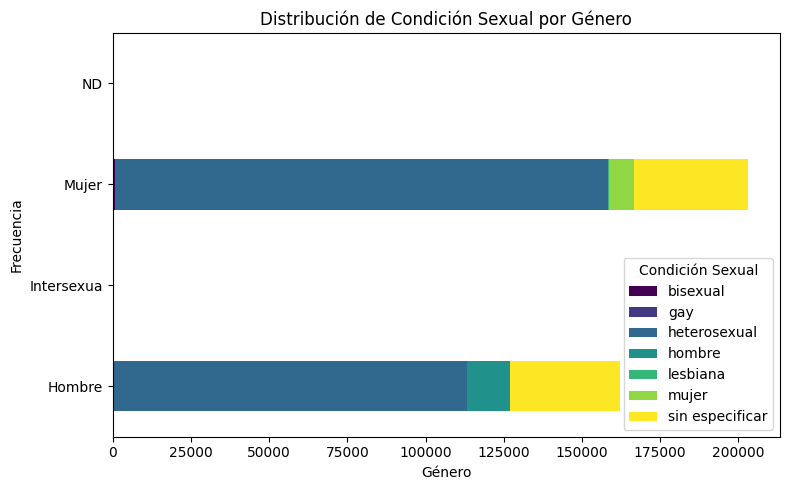

In [25]:
import matplotlib.pyplot as plt

df.groupby(['Genero', 'CondicionSexual']).size().unstack().plot(
    kind='barh',
    stacked=True,
    figsize=(8,5),
    colormap='viridis'
)
plt.title('Distribución de Condición Sexual por Género')
plt.xlabel('Género')
plt.ylabel('Frecuencia')
plt.legend(title='Condición Sexual')
plt.tight_layout()
plt.show()



In [26]:
# Filtrar solo las mujeres
mujeres = df[df['Genero'].str.lower().isin(['mujer'])]

# Contar frecuencia de cada categoría
distribucion_mujer = mujeres['CondicionSexual'].value_counts(dropna=False)

print(distribucion_mujer)

CondicionSexual
heterosexual       157536
sin especificar     36631
mujer                8035
bisexual              855
lesbiana               88
hombre                 32
gay                     6
Name: count, dtype: int64


In [27]:
# Filtrar solo para hombres
hombres = df[df['Genero'].str.lower().isin(['hombre'])]

# Contar frecuencia de cada categoría
distribucion_hombres = hombres['CondicionSexual'].value_counts(dropna=False)

print(distribucion_hombres)

CondicionSexual
heterosexual       112711
sin especificar     35072
hombre              13832
bisexual              424
gay                    51
mujer                  40
lesbiana               11
Name: count, dtype: int64


In [28]:
# Agrupar por genero y obtener la moda de la columna CondicionSexual
moda_por_genero = (
    df.groupby('Genero')['CondicionSexual']
      .agg(lambda x: x.mode().iat[0] if not x.mode().empty else None)
)

print(moda_por_genero)

Genero
Hombre           heterosexual
Intersexua       heterosexual
Mujer            heterosexual
ND            sin especificar
Name: CondicionSexual, dtype: object


In [29]:
# Teniendo presente que para ambos generos la moda es heterosexual, tanto para las imputaciones mujer y hombre, se les asignara Heterosexual
reemplazos = {
    'hombre': 'heterosexual',
    'mujer':'heterosexual',
}

df['CondicionSexual'] = df['CondicionSexual'].replace(reemplazos)
df['CondicionSexual'].value_counts()

CondicionSexual
heterosexual       292206
sin especificar     71853
bisexual             1279
lesbiana               99
gay                    57
Name: count, dtype: int64

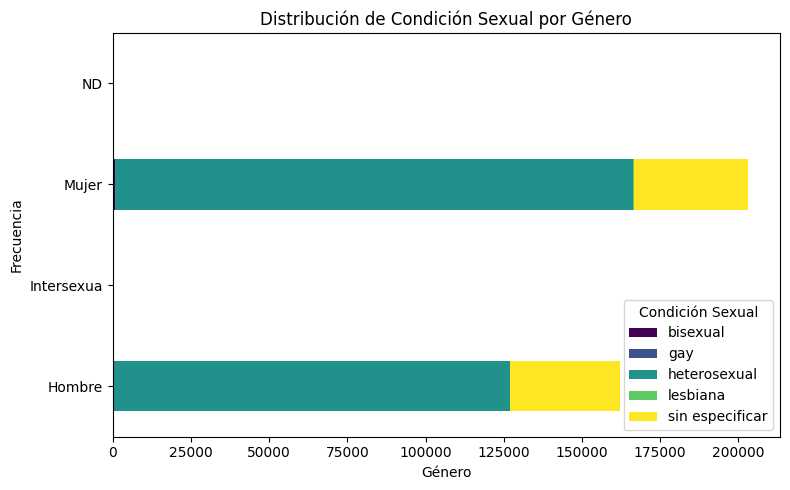

In [30]:
#Graficar nuevamente para ver como quedo distribuida la variable
df.groupby(['Genero', 'CondicionSexual']).size().unstack().plot(
    kind='barh',
    stacked=True,
    figsize=(8,5),
    colormap='viridis'
)
plt.title('Distribución de Condición Sexual por Género')
plt.xlabel('Género')
plt.ylabel('Frecuencia')
plt.legend(title='Condición Sexual')
plt.tight_layout()
plt.show()

In [31]:
#Discapacidad   
df.Discapacidad.unique()

array(['NO', 'ND', 'SI'], dtype=object)

In [32]:
#EstadoBeneficiario 
df.EstadoBeneficiario.unique()

array(['NO ACTIVO', 'ATENDIDO', 'ACTIVO', 'RETIRADO',
       'VINCULADO-INSCRITO', 'FALLECIDO'], dtype=object)

In [33]:
#EstadoCivil   
df.EstadoCivil.unique()

array(['SO', 'Casado(a)', 'ND', 'CA', 'Unión libre', 'UL', 'VI',
       'Soltero(a)', 'DI', 'Viudo(a)', 'NO REPORTA', 'DIVORCIADO(A)',
       'Sin Informació', 'Separado(a) o', 'VIVE EN PAREJA'], dtype=object)

In [34]:
df['EstadoCivil'].value_counts()

EstadoCivil
Soltero(a)        112548
Unión libre       105702
Casado(a)          37997
Sin Informació     33839
Separado(a) o      16632
NO REPORTA         13553
ND                 12438
Viudo(a)           10652
UL                  7239
CA                  5193
SO                  4664
DIVORCIADO(A)       2230
VI                  1308
DI                  1220
VIVE EN PAREJA       279
Name: count, dtype: int64

In [35]:
#Pasamos todo a minusculas para que sea mas sencillo trabajar
df['EstadoCivil'] = df['EstadoCivil'].str.lower().str.strip()
df['EstadoCivil'].value_counts()

EstadoCivil
soltero(a)        112548
unión libre       105702
casado(a)          37997
sin informació     33839
separado(a) o      16632
no reporta         13553
nd                 12438
viudo(a)           10652
ul                  7239
ca                  5193
so                  4664
divorciado(a)       2230
vi                  1308
di                  1220
vive en pareja       279
Name: count, dtype: int64

In [36]:

reemplazos = {
    'so': 'soltero(a)',
    'ul': 'unión libre',
    'ca': 'casado(a)',
    'sin informació':'sin información',
    'no reporta':'sin información',
    'nd':'sin información',
    'separado(a) o': 'separado(a)',
    'divorciado(a)': 'separado(a)',
    'di': 'separado(a)',
    'vi': 'viudo(a)',
    'no responde':'sin especificar'
}

df['EstadoCivil'] = df['EstadoCivil'].replace(reemplazos)
df['EstadoCivil'].value_counts()

EstadoCivil
soltero(a)         117212
unión libre        112941
sin información     59830
casado(a)           43190
separado(a)         20082
viudo(a)            11960
vive en pareja        279
Name: count, dtype: int64

In [37]:
#Etnia
df.Etnia.unique()

array(['ND', 'AFROCOLOMBIANO – NEGRO', 'INDIGENA', 'PALENQUERO',
       'Indígena', 'SIN ESPECIFICAR', 'RAIZAL', 'ROM O GITANO', 'MESTIZO',
       'ROM', 'AFROCOLOMBIANO - NEGRO'], dtype=object)

In [38]:
df['Etnia'].value_counts()

Etnia
ND                        346191
AFROCOLOMBIANO – NEGRO     12326
Indígena                    3667
INDIGENA                    2220
RAIZAL                       565
PALENQUERO                   229
ROM O GITANO                 174
ROM                           75
MESTIZO                       29
SIN ESPECIFICAR               14
AFROCOLOMBIANO - NEGRO         4
Name: count, dtype: int64

In [39]:
#Pasamos todo a minusculas para que sea mas sencillo trabajar
df['Etnia'] = df['Etnia'].str.lower().str.strip()
df['Etnia'].value_counts()

Etnia
nd                        346191
afrocolombiano – negro     12326
indígena                    3667
indigena                    2220
raizal                       565
palenquero                   229
rom o gitano                 174
rom                           75
mestizo                       29
sin especificar               14
afrocolombiano - negro         4
Name: count, dtype: int64

In [40]:
reemplazos = {
    'nd': 'sin especificar',
    'afrocolombiano – negro': 'afrocolombiano',
    'afrocolombiano - negro': 'afrocolombiano',
    'indígena':'indigena',
    'rom':'rom o gitano'
}

df['Etnia'] = df['Etnia'].replace(reemplazos)
df['Etnia'].value_counts()

Etnia
sin especificar    346205
afrocolombiano      12330
indigena             5887
raizal                565
rom o gitano          249
palenquero            229
mestizo                29
Name: count, dtype: int64

In [41]:
#FechaInscripcionBeneficiario
df.FechaInscripcionBeneficiario.unique()

array(['2018-03-01', '2019-01-01', '2016-04-01', '2016-12-01',
       '2021-01-01', '2020-01-01', '2017-02-01', '2017-01-01',
       '2018-04-01', '2018-02-01', '2018-07-01', '2017-04-01',
       '2018-06-01', '2022-01-01', '2018-08-01', '2018-05-01',
       '2017-05-01', '2018-01-01', '2017-03-01', '2018-09-01',
       '2017-08-01', '2017-06-01', '2018-11-01', '2017-07-01'],
      dtype=object)

In [42]:
#FechaUltimoBeneficioAsignado
df.FechaUltimoBeneficioAsignado.unique()

array(['2018-01-01', '2019-01-01', '2014-01-01', '2017-01-01',
       '1900-01-01', '2013-01-01', '2022-01-01', '2016-01-01',
       '2015-01-01', '2020-01-01', '2021-01-01', '2002-01-01'],
      dtype=object)

In [43]:
#Genero
df.Genero.unique()

array(['Hombre', 'Mujer', 'ND', 'Intersexua'], dtype=object)

In [44]:
#NivelEscolaridad
df.NivelEscolaridad.unique()

array(['PRIMARIA', 'Básica primaria (1o. - 5o.)', 'ND', 'SIN ESPECIFICAR',
       'Ninguno', 'TRANSICION', 'TECNICO', 'Básica Secundaria (6o - 9o)',
       'Preescolar', 'Media (10o - 13o)', 'SECUNDARIA',
       'TÉCNICA PROFESIONAL', 'Universitario (1-6)', 'TECNOLOGO',
       'TECNOLÓGICO', 'PROFESIONAL', 'Técnico o tecnológico (1-4)',
       'PREGRADO', 'NINGUNO', 'CURSO LARGO SENA 400 HR', 'MAESTRÍA',
       'CURSO CORTO SENA 40 HR', 'ESPECIALIZACIÓN',
       'CERTIFICACIÓN HABILIDADES SENA', 'POSGRADO', 'Posgrado (1-4)',
       'DOCTORADO'], dtype=object)

In [45]:
df['NivelEscolaridad'].value_counts()

NivelEscolaridad
Básica primaria (1o. - 5o.)       124701
ND                                 57184
Media (10o - 13o)                  53283
Básica Secundaria (6o - 9o)        49200
Ninguno                            37364
SIN ESPECIFICAR                    12186
PRIMARIA                            6587
Preescolar                          6196
TÉCNICA PROFESIONAL                 4554
SECUNDARIA                          3056
Técnico o tecnológico (1-4)         2919
NINGUNO                             2910
TECNOLÓGICO                         1613
PROFESIONAL                         1449
Universitario (1-6)                  942
TECNICO                              318
CURSO LARGO SENA 400 HR              230
TRANSICION                           226
CURSO CORTO SENA 40 HR               166
TECNOLOGO                            126
PREGRADO                              86
CERTIFICACIÓN HABILIDADES SENA        63
ESPECIALIZACIÓN                       62
MAESTRÍA                              40

In [46]:
#Pasamos todo a minusculas para que sea mas sencillo trabajar
df['NivelEscolaridad'] = df['NivelEscolaridad'].str.lower().str.strip()
df['NivelEscolaridad'].value_counts()

NivelEscolaridad
básica primaria (1o. - 5o.)       124701
nd                                 57184
media (10o - 13o)                  53283
básica secundaria (6o - 9o)        49200
ninguno                            40274
sin especificar                    12186
primaria                            6587
preescolar                          6196
técnica profesional                 4554
secundaria                          3056
técnico o tecnológico (1-4)         2919
tecnológico                         1613
profesional                         1449
universitario (1-6)                  942
tecnico                              318
curso largo sena 400 hr              230
transicion                           226
curso corto sena 40 hr               166
tecnologo                            126
pregrado                              86
certificación habilidades sena        63
especialización                       62
maestría                              40
posgrado (1-4)                        24

In [47]:
reemplazos = {
    'primaria': 'básica primaria (1o. - 5o.)',
    'nd': 'sin especificar',
    'universitario (1-6)': 'profesional',
    'pregrado': 'profesional',
    'tecnologo':'tecnológico',
    'posgrado (1-4)':'posgrado'
}

df['NivelEscolaridad'] = df['NivelEscolaridad'].replace(reemplazos)
df['NivelEscolaridad'].value_counts()

NivelEscolaridad
básica primaria (1o. - 5o.)       131288
sin especificar                    69370
media (10o - 13o)                  53283
básica secundaria (6o - 9o)        49200
ninguno                            40274
preescolar                          6196
técnica profesional                 4554
secundaria                          3056
técnico o tecnológico (1-4)         2919
profesional                         2477
tecnológico                         1739
tecnico                              318
curso largo sena 400 hr              230
transicion                           226
curso corto sena 40 hr               166
certificación habilidades sena        63
especialización                       62
maestría                              40
posgrado                              30
doctorado                              3
Name: count, dtype: int64

In [48]:
#NombreDepartamentoAtencion
df.NombreDepartamentoAtencion.unique()

array(['CUNDINAMARCA', 'MAGDALENA', 'ANTIOQUIA', 'META', 'CHOCO', 'SUCRE',
       'CESAR', 'CAQUETA', 'CORDOBA', 'PUTUMAYO', 'BOLIVAR', 'TOLIMA',
       'LA GUAJIRA', 'NORTE DE SANTANDER', 'RISARALDA', 'CALDAS',
       'SANTANDER', 'CAUCA', 'NARIÑO', 'ARAUCA', 'VALLE', 'GUAVIARE',
       'ATLANTICO', 'BOGOTA', 'HUILA', 'CÓRDOBA', 'VALLE DEL CAUCA',
       'BOYACA', 'AMAZONAS', 'CASANARE', 'QUINDIO'], dtype=object)

In [49]:
#NombreMunicipioAtencion
df.NombreMunicipioAtencion.unique()

array(['LA PALMA', 'PIVIJAY', 'SAN LUIS', 'EL CASTILLO', 'APARTADO',
       'UNGUIA', 'COLOSO', 'SITIONUEVO', 'LA JAGUA DE IBIRICO',
       'SAN DIEGO', 'LA MONTAÑITA', 'TOPAIPÍ', 'MONTELIBANO', 'CHIGORODO',
       'VALENCIA', 'VALLEDUPAR', 'OVEJAS', 'PUERTO CAICEDO',
       'SAN BENITO ABAD', 'SAN PABLO', 'DABEIBA', 'NECHÍ', 'ACACIAS',
       'BELEN DE LOS ANDAQUIES', 'FRESNO', 'VILLANUEVA', 'CONVENCION',
       'GRANADA', 'SAN FRANCISCO', 'EL PEÑÓN', 'SAN RAFAEL', 'CURUMANI',
       'BAGADO', 'SAN CALIXTO', 'CHIGORODÓ', 'URRAO', 'PUEBLO RICO',
       'SAN JUAN DEL CESAR', 'MARÍA LA BAJA', 'FUNDACION', 'RIOSUCIO',
       'SAMANÁ', 'EL CARMEN DE BOLIVAR', 'BARRANCABERMEJA', 'SONSON',
       'MORALES', 'PUERTO TRIUNFO', 'OLAYA HERRERA', 'REMOLINO',
       'ARGELIA', 'CAREPA', 'LA LLANADA', 'PENSILVANIA',
       'CARMEN DEL DARIEN', 'VALLE DEL GUAMUEZ', 'SANTA BARBARA', 'TURBO',
       'PUERTO ASIS', 'TOLU VIEJO', 'ARAUQUITA', 'SAN JUAN DE URABA',
       'ASTREA', 'QUINCHÍA', 'RIOHACHA',

In [50]:
#Pais
df.Pais.unique() #La informacion que estamos analizando es de colombia y confirmando que todos los codigos son 
                 # son colombianos, podemos eliminar dicha columna ya que no aporta informacion

array(['COLOMBIA', 'Colombia', '169', 'ND', '57'], dtype=object)

In [51]:
df = df.drop(columns=['Pais'])

display(df)

,CantidadDeBeneficiarios,CantidadBeneficioConsolidado,CantidadUltimobeneficio,CondicionSexual,Discapacidad,EstadoBeneficiario,EstadoCivil,Etnia,FechaInscripcionBeneficiario,FechaUltimoBeneficioAsignado,...,NombreDepartamentoAtencion,NombreMunicipioAtencion,Parentesco,RangoEdad,TipoAsignacionBeneficio,TipoBeneficio,TipoDocumento,TipoPoblacion,RangoValorBeneficioConsolidadoAsignado,RangoValorUltimoBeneficioAsignado
0,1,2,1,heterosexual,NO,NO ACTIVO,soltero(a),sin especificar,2018-03-01,2018-01-01,...,CUNDINAMARCA,LA PALMA,ND,>65,RURAL,MONETARIO Y EN ESPECIE,CC,DESPLAZADOS,1.500.001 - 3.000.000,0 - 1.300.000
1,1,1,1,heterosexual,NO,ATENDIDO,casado(a),sin especificar,2019-01-01,2019-01-01,...,MAGDALENA,PIVIJAY,Jefe del hogar,30-49,INCENTIVO IDEA PRODUCTIVA,INCENTIVO DE IDEA PRODUCTIVA,CC,DESPLAZADOS,1.500.001 - 3.000.000,1.300.001 - 2.600.000
2,1,4,1,sin especificar,ND,ACTIVO,sin información,sin especificar,2016-04-01,2014-01-01,...,ANTIOQUIA,SAN LUIS,ND,>65,RURAL,MONETARIO Y EN ESPECIE,CC,AMBAS CONDICIONES,4.500.001 - 6.000.000,2.600.001 - 3.900.000
3,1,3,1,sin especificar,ND,ACTIVO,sin información,sin especificar,2016-12-01,2017-01-01,...,META,EL CASTILLO,ND,>65,RURAL,MONETARIO Y EN ESPECIE,CC,AMBAS CONDICIONES,3.000.001 - 4.500.000,1.300.001 - 2.600.000
4,1,4,1,heterosexual,NO,NO ACTIVO,sin información,sin especificar,2016-04-01,2014-01-01,...,ANTIOQUIA,APARTADO,ND,>65,RURAL,MONETARIO Y EN ESPECIE,CC,AMBAS CONDICIONES,4.500.001 - 6.000.000,2.600.001 - 3.900.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
365489,2,5,1,sin especificar,NO,NO ACTIVO,sin información,sin especificar,2016-04-01,2016-01-01,...,ANTIOQUIA,APARTADO,ND,>65,RURAL,MONETARIO Y EN ESPECIE,CC,DESPLAZADOS,4.500.001 - 6.000.000,1.300.001 - 2.600.000
365490,4,4,1,sin especificar,NO,ACTIVO,sin información,sin especificar,2016-04-01,2014-01-01,...,CUNDINAMARCA,LA PALMA,ND,50-65,RURAL,MONETARIO Y EN ESPECIE,CC,DESPLAZADOS,5486000,2654000
365491,6,5,1,sin especificar,NO,ACTIVO,sin información,sin especificar,2016-04-01,2016-01-01,...,TOLIMA,ATACO,ND,30-49,RURAL,MONETARIO Y EN ESPECIE,CC,DESPLAZADOS,5508000,2600000
365492,1,4,1,sin especificar,NO,ACTIVO,sin información,sin especificar,2016-04-01,2014-01-01,...,ANTIOQUIA,CHIGORODO,ND,50-65,RURAL,MONETARIO Y EN ESPECIE,CC,AMBAS CONDICIONES,5486000,2654000


In [52]:
#Parentesco
df.Parentesco.unique()

array(['ND', 'Jefe del hogar', 'Cónyuge o compañero(a)',
       'Hijo(a) o hijastro(a) o hijo(a) adoptivo', 'NO REPORTA',
       'Padre madre padrastro madrastra', 'OTRO PARIENTE',
       'SIN INFORMACION', 'Otro pariente', 'HIJASTRO[A]', 'CONYUGE',
       'Abuelo (a)', 'Nieto(a)', 'JEFE DE HOGAR', 'Hermano(a)', 'HIJO[A]',
       'PADRES(PADRE/MADRE)', 'Primo(a)', 'HERMANOS(HERMANO[A])',
       'Suegro (a)', 'Yerno / Nuera', 'Sobrino(a)', 'Otro no pariente',
       'Cuñado(a)', 'Tío(a)', 'JEFE  DE HOGAR', 'SUEGROS (SUEGRO[A])',
       'CONYUGUE'], dtype=object)

In [53]:
df['Parentesco'].value_counts()

Parentesco
Jefe del hogar                              193160
ND                                           64533
Hijo(a) o hijastro(a) o hijo(a) adoptivo     41603
NO REPORTA                                   35217
Cónyuge o compañero(a)                       20033
Nieto(a)                                      2789
Otro pariente                                 2668
Padre madre padrastro madrastra               1737
Hermano(a)                                    1015
OTRO PARIENTE                                  717
HIJASTRO[A]                                    529
JEFE DE HOGAR                                  291
Sobrino(a)                                     264
CONYUGE                                        208
Yerno / Nuera                                  128
Abuelo (a)                                     118
Tío(a)                                          87
Suegro (a)                                      84
Otro no pariente                                79
SIN INFORMACION     

In [54]:
#Pasamos todo a minusculas para que sea mas sencillo trabajar
df['Parentesco'] = df['Parentesco'].str.lower().str.strip()
df['Parentesco'].value_counts()

Parentesco
jefe del hogar                              193160
nd                                           64533
hijo(a) o hijastro(a) o hijo(a) adoptivo     41603
no reporta                                   35217
cónyuge o compañero(a)                       20033
otro pariente                                 3385
nieto(a)                                      2789
padre madre padrastro madrastra               1737
hermano(a)                                    1015
hijastro[a]                                    529
jefe de hogar                                  291
sobrino(a)                                     264
conyuge                                        208
yerno / nuera                                  128
abuelo (a)                                     118
tío(a)                                          87
suegro (a)                                      84
otro no pariente                                79
sin informacion                                 71
cuñado(a)           

In [55]:
# Reemplazamos los valores de "Parentesco" por su grado de consanguinidad o afinidad, así:
reemplazos = {
    'conyuge': 'consanguinidad1',
    'conyugue': 'consanguinidad1',
    'cónyuge o compañero(a)': 'consanguinidad1',
    'yerno / nuera': 'consanguinidad1',
    'padres(padre/madre)':'consanguinidad1',
    'padre madre padrastro madrastra': 'consanguinidad1',
    'hijastro[a]': 'consanguinidad1',
    'hijo[a]': 'consanguinidad1',
    'hijo(a) o hijastro(a) o hijo(a) adoptivo': 'consanguinidad1',
    'hermanos(hermano[a])': 'consanguinidad2',
    'hermano(a)': 'consanguinidad2',
    'abuelo (a)': 'consanguinidad2',
    'nieto(a)': 'consanguinidad2',
    'tío(a)': 'consanguinidad3',
    'sobrino(a)': 'consanguinidad3',
    'primo(a)': 'consanguinidad4',
    'jefe de hogar': 'otro parentesco',
    'jefe  de hogar': 'otro parentesco',
    'jefe del hogar': 'otro parentesco',
    'otro pariente': 'otro parentesco',
    'otro no pariente': 'otro parentesco',
    'suegros (suegro[a])': 'afinidad1',
    'suegro (a)': 'afinidad1',
    'cuñado(a)': 'afinidad2',
    'no reporta':'sin informacion',
    'nd': 'sin informacion'
}

df['Parentesco'] = df['Parentesco'].replace(reemplazos)
df['Parentesco'].value_counts()

Parentesco
otro parentesco    196919
sin informacion     99821
consanguinidad1     64284
consanguinidad2      3930
consanguinidad3       351
afinidad1              86
afinidad2              57
consanguinidad4        46
Name: count, dtype: int64

In [56]:
#RangoEdad
df.RangoEdad.unique()

array(['>65', '30-49', '50-65', '18-29', '06-17', '00-05'], dtype=object)

In [57]:
#TipoAsignacionBeneficio
df.TipoAsignacionBeneficio.unique()

array(['RURAL', 'INCENTIVO IDEA PRODUCTIVA', 'ND',
       'HABITAT Y HABITABILIDAD', 'SEGURIDAD ALIMENTARIA'], dtype=object)

In [58]:
#TipoBeneficio
df.TipoBeneficio.unique()

array(['MONETARIO Y EN ESPECIE', 'INCENTIVO DE IDEA PRODUCTIVA', 'ND',
       'HABITAT Y HABITABILIDAD', 'SEGURIDAD ALIMENTARIA'], dtype=object)

In [59]:
#TipoDocumento
df.TipoDocumento.unique()

array(['CC', 'RC', 'TI', 'CE', 'No Definido', 'NUIP', 'SAL', 'PEP', 'PA',
       'DNI'], dtype=object)

In [60]:
#TipoPoblacion
df.TipoPoblacion.unique()

array(['DESPLAZADOS', 'AMBAS CONDICIONES', 'DOBLE CONDICION',
       'VULNERABLE', 'UNIDOS'], dtype=object)

In [61]:
#RangoValorBeneficioConsolidadoAsignado
df.RangoValorBeneficioConsolidadoAsignado.unique()

array(['1.500.001 - 3.000.000', '4.500.001 - 6.000.000',
       '3.000.001 - 4.500.000', '0 - 1.500.000', '3.000.001 o más',
       '4433000', '5486000', '5508000', '1000000', '800000', '400000',
       '3033000', '5331629', '1833000', '4708000', '2100000', '3008000',
       '2500000', '4308000', '433000', '1200000', '4565777', '2908000',
       '1608000', '200000', '1008000', '808000', '5286000', '4286000',
       '408000', '600000', '1400000', '5108000', '2832000', '2600000',
       '4947237', '5284065', '1224000', '4886000', '4974273', '4895821',
       '4208000', '4262000', '4000000', '3408000', '5178521', '5078000',
       '1632000', '4812365', '4283148', '5177661', '4381221', '2424000',
       '1208000', '3854000', '4536378', '4804733', '5021473', '4893293',
       '4760164', '4896831', '5404565', '5086000', '4976050', '5009727',
       '3062000', '5130809', '4708389', '5243969', '5377820', '5324236',
       '4965501', '4547050', '2108000', '5203622', '5401565', '4717590',
      

In [62]:
#RangoValorUltimoBeneficioAsignado
df.RangoValorUltimoBeneficioAsignado.unique()

array(['0 - 1.300.000', '1.300.001 - 2.600.000', '2.600.001 - 3.900.000',
       '2.600.001 o más', '2600000', '2654000', '1000000', '800000',
       '400000', '200000', '1400000', '1224000', '433000', '1300000',
       '408000', '1200000', '600000'], dtype=object)

ANALISIS EXPLORATORIO 

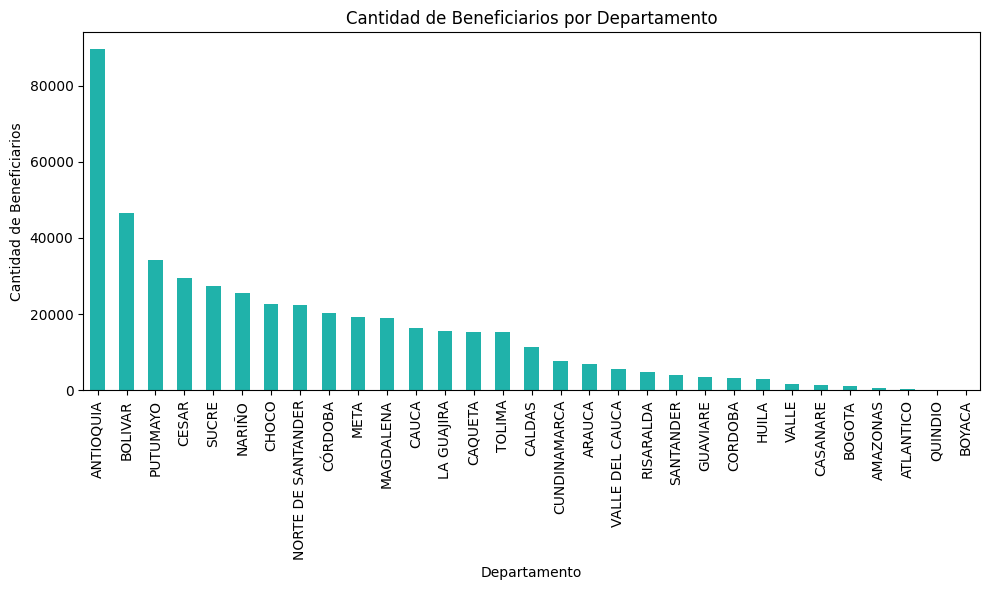

In [ ]:
#Cantidad de beneficiarios por departamento
depxbeneficio = df.groupby("NombreDepartamentoAtencion")["CantidadDeBeneficiarios"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
depxbeneficio.plot(kind="bar", color='lightseagreen')
plt.title("Cantidad de Beneficiarios por Departamento")
plt.xlabel("Departamento")
plt.ylabel("Cantidad de Beneficiarios")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


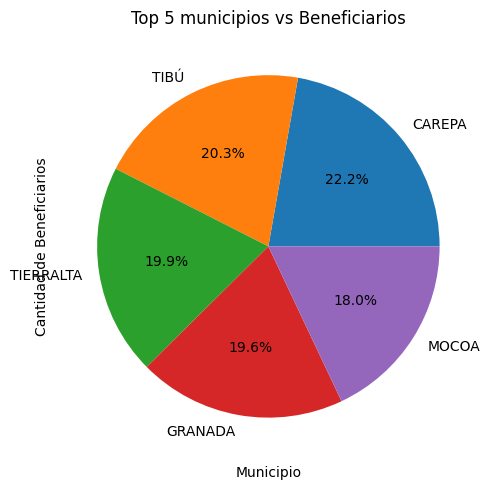

In [ ]:
#Cuales fueron los municipios mas beneficiados
top_mun = df.groupby("NombreMunicipioAtencion")["CantidadDeBeneficiarios"].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(8,5))
top_mun.plot(kind="pie", color='goldenrod',  autopct='%1.1f%%')
plt.title(f"Top 5 municipios vs Beneficiarios")
plt.xlabel("Municipio")
plt.ylabel("Cantidad de Beneficiarios")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




<Figure size 1000x600 with 0 Axes>

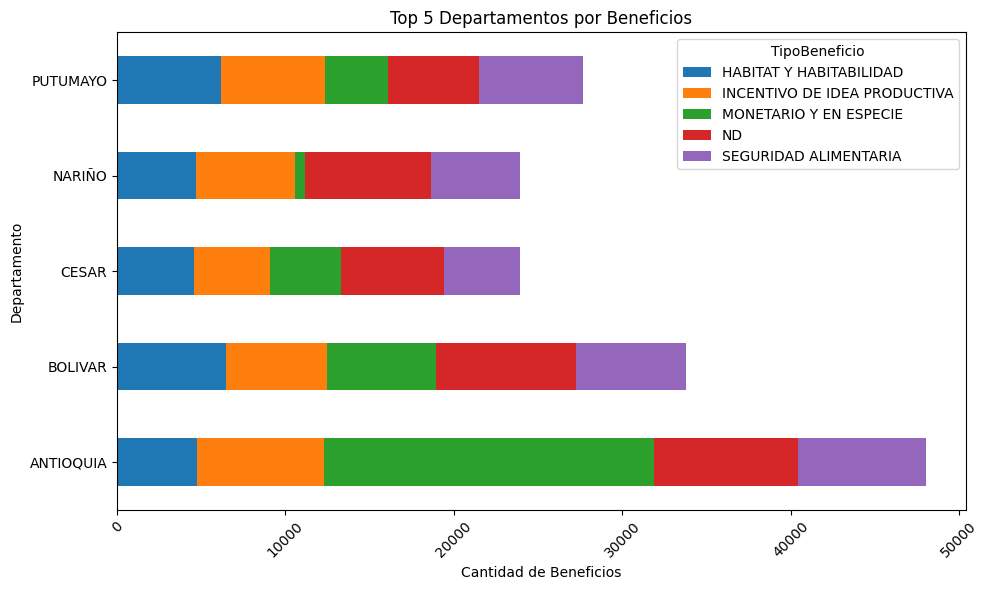

In [ ]:
#Cual fue el tipo de beneficio que recibieron en los departamentos mas beneficiados
top_dep = (df.groupby("NombreDepartamentoAtencion")["TipoBeneficio"].count().sort_values(ascending=False).head(5))

df_top = df[df["NombreDepartamentoAtencion"].isin(top_dep.index)]

tabla = (df_top.groupby(["NombreDepartamentoAtencion", "TipoBeneficio"]).size().unstack(fill_value=0))

plt.figure(figsize=(10,6))
tabla.plot(kind="barh", stacked=True, figsize=(10,6))

plt.title("Top 5 Departamentos por Beneficios")
plt.xlabel("Cantidad de Beneficios")
plt.ylabel("Departamento")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

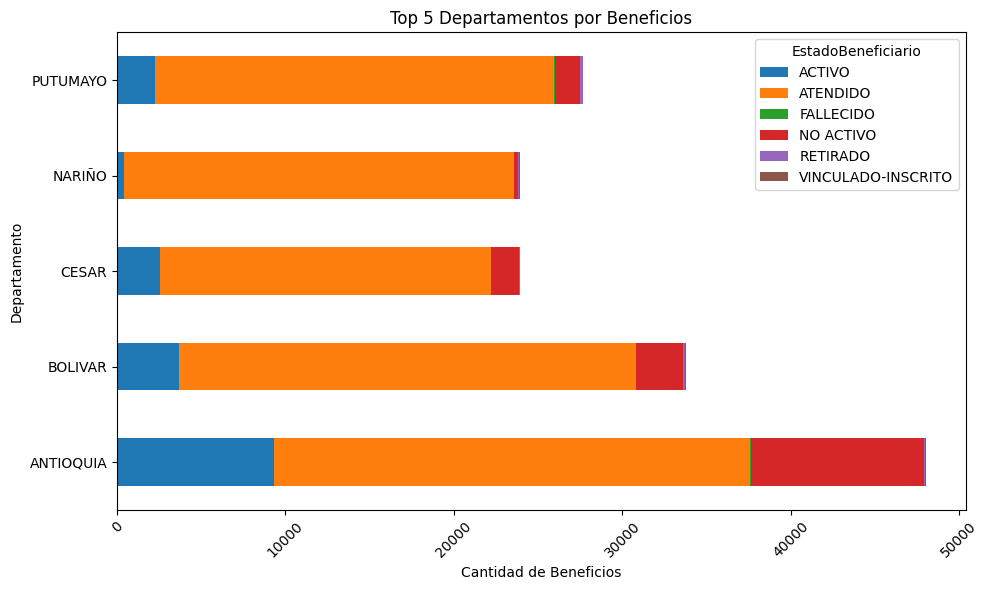

In [ ]:
#Cuales fueron los departamentos con mayor beneficio y sus respectivos estados
top_dep = (df.groupby("NombreDepartamentoAtencion")["EstadoBeneficiario"].count().sort_values(ascending=False).head(5))

df_top = df[df["NombreDepartamentoAtencion"].isin(top_dep.index)]

tabla = (df_top.groupby(["NombreDepartamentoAtencion", "EstadoBeneficiario"]).size().unstack(fill_value=0))

plt.figure(figsize=(10,6))
tabla.plot(kind="barh", stacked=True, figsize=(10,6))

plt.title("Top 5 Departamentos por Beneficios")
plt.xlabel("Cantidad de Beneficios")
plt.ylabel("Departamento")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()